#Configuração do Ambiente e Dados Iniciais

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Gerando dados sintéticos estruturados
np.random.seed(42)
n_registros = 120

datas = pd.date_range(start='2024-01-01', periods=n_registros, freq='D')
categorias = ['Eletronicos', 'Livros', 'Roupas', 'Automotivo']
estados = ['SP', 'RJ', 'MG', 'RS', 'BA']

dados = {
    'data': datas,
    'categoria': np.random.choice(categorias, size=n_registros),
    'estado': np.random.choice(estados, size=n_registros),
    'valor': np.random.uniform(50, 4500, size=n_registros).round(2),
    'quantidade': np.random.randint(1, 15, size=n_registros),
}

df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

#Tarefas do Exercício

##Parte 1: Gráficos Essenciais e Personalização (Básico)

Construa um gráfico de linha (plt.plot ou ax.plot) mostrando o faturamento mensal total (resample('ME')). Adicione marcadores circulares ('o'), linha tracejada ('--'), cor customizada, grade (grid) e rótulos para os eixos X e Y.

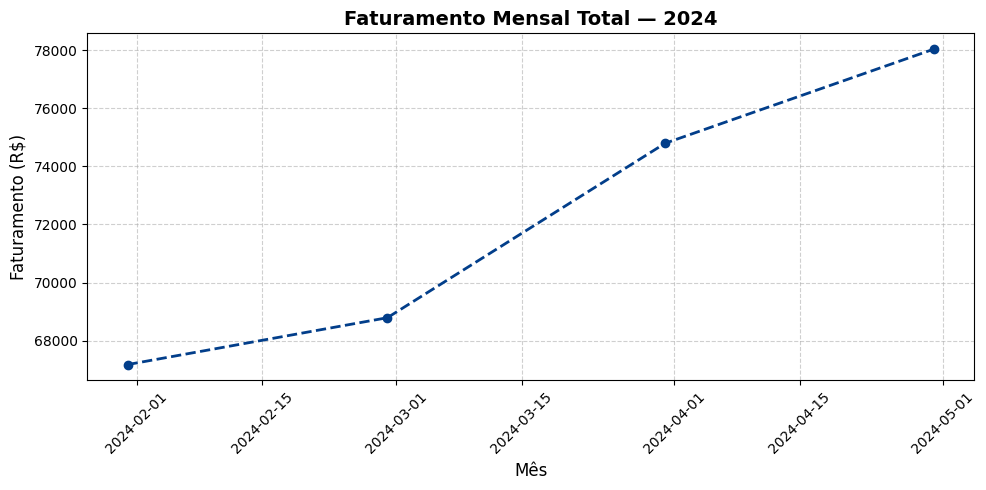

In [ ]:
df_mensal = df.set_index('data')['valor_venda'].resample('ME').sum()

plt.figure(figsize=(10, 5))
plt.plot(df_mensal.index, df_mensal.values, marker='o', linestyle='--', color='#023e8a', linewidth=2)
plt.title('Faturamento Mensal Total — 2024', fontsize=14, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Crie um gráfico de barras (plt.bar) com o total de vendas por categoria ordenado do menor para o maior valor, rotacionando os rótulos do eixo X em 45 graus.

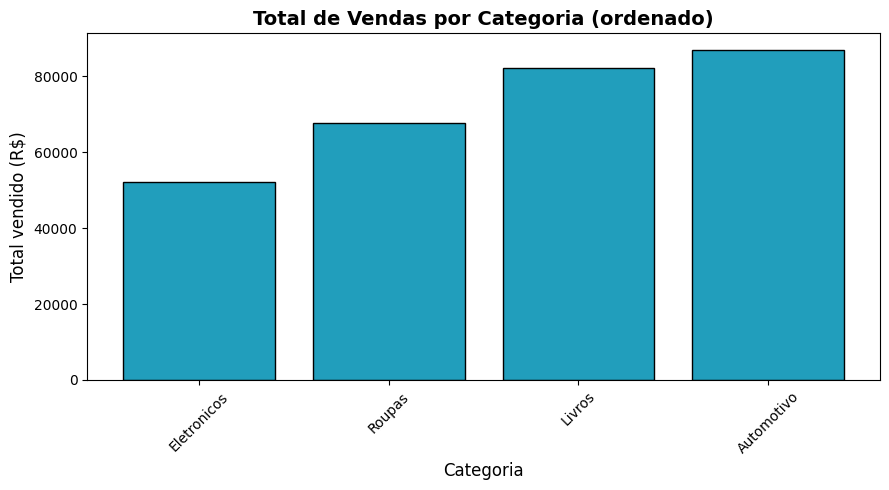

In [ ]:
vendas_categoria = df.groupby('categoria')['valor_venda'].sum().sort_values()

plt.figure(figsize=(9, 5))
plt.bar(vendas_categoria.index, vendas_categoria.values, color='#219ebc', edgecolor='black')

plt.title('Total de Vendas por Categoria (ordenado)', fontsize=14, fontweight='bold')
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Total vendido (R$)', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Crie um histograma (plt.hist) da coluna valor com 10 bins e bordas destacadas (edgecolor='black') para analisar a distribuição dos valores das vendas.

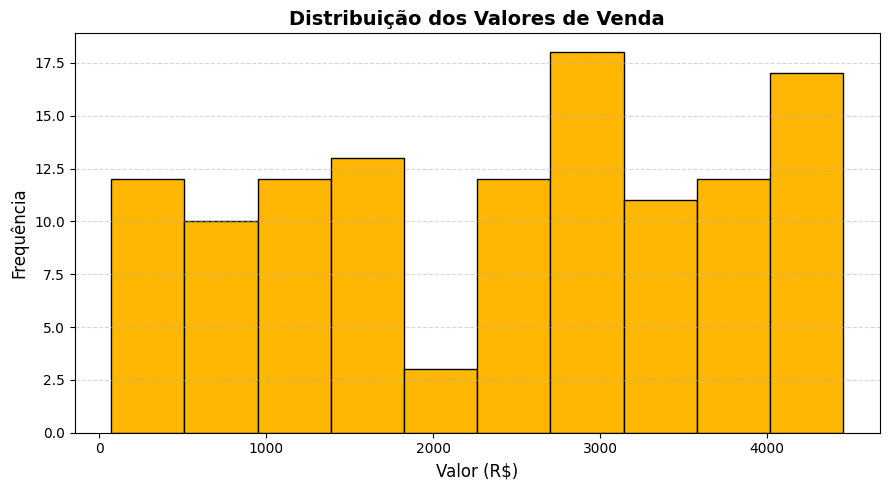

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(df['valor'], bins=10, color='#ffb703', edgecolor='black')

plt.title('Distribuição dos Valores de Venda', fontsize=14, fontweight='bold')
plt.xlabel('Valor (R$)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##Parte 2: API Orientada a Objetos e Eixos Múltiplos (Intermediário)

 Crie uma figura com uma grade 2 x 1 de subplots (fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)) com o eixo X compartilhado:

*   ax1 (Superior): Gráfico de linha com o faturamento mensal.
*   ax2 (Inferior): Gráfico de barras com a quantidade total de itens vendidos no mesmo período.




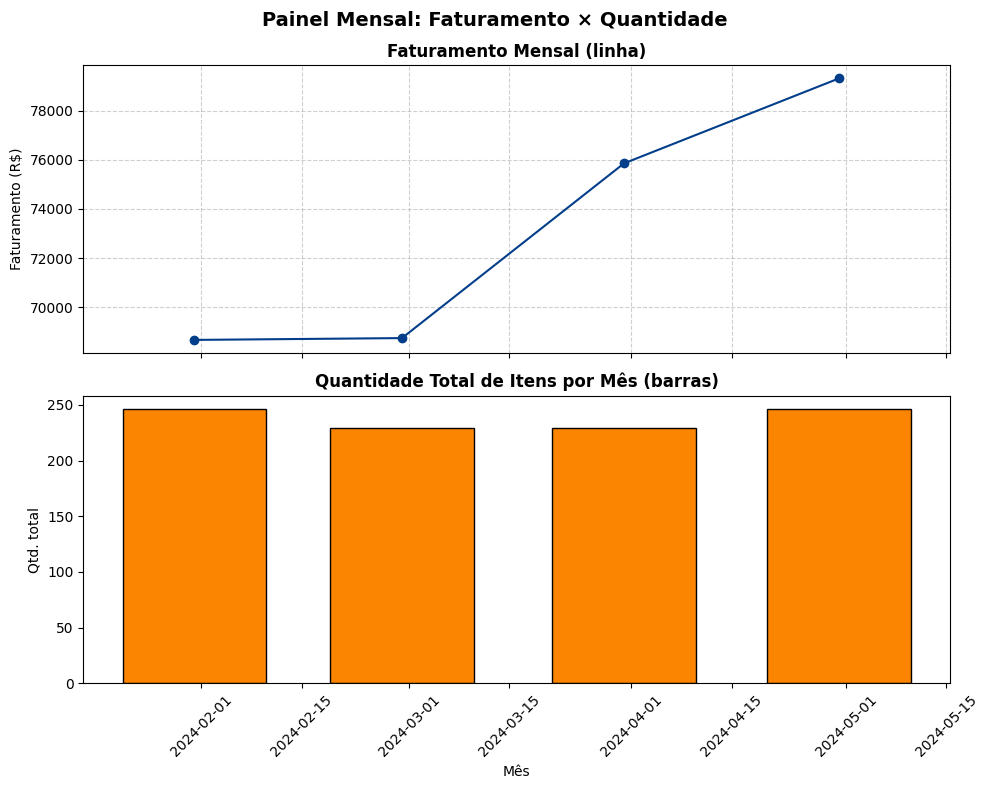

In [ ]:
df = pd.DataFrame(dados)
df['valor_venda'] = (df['valor'] * np.random.uniform(0.9, 1.1, size=n_registros)).round(2)

df_mensal = df.set_index('data').resample('ME').agg({'valor_venda': 'sum', 'quantidade': 'sum'})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

#ax1
ax1.plot(df_mensal.index, df_mensal['valor_venda'], marker='o', linestyle='-', color='#023e8a')
ax1.set_title('Faturamento Mensal (linha)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Faturamento (R$)')
ax1.grid(True, linestyle='--', alpha=0.6)

#ax2
ax2.bar(df_mensal.index, df_mensal['quantidade'], color='#fb8500', edgecolor='black', width=20)
ax2.set_title('Quantidade Total de Itens por Mês (barras)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mês')
ax2.set_ylabel('Qtd. total')
ax2.tick_params(axis='x', rotation=45)

fig.suptitle('Painel Mensal: Faturamento × Quantidade', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

Crie um gráfico com dois eixos Y (ax.twinx()):
* No eixo primário (à esquerda), exiba o valor total vendido por mês em barras.
* No eixo secundário (à direita), plote a quantidade média de itens por venda em linha com marcadores.

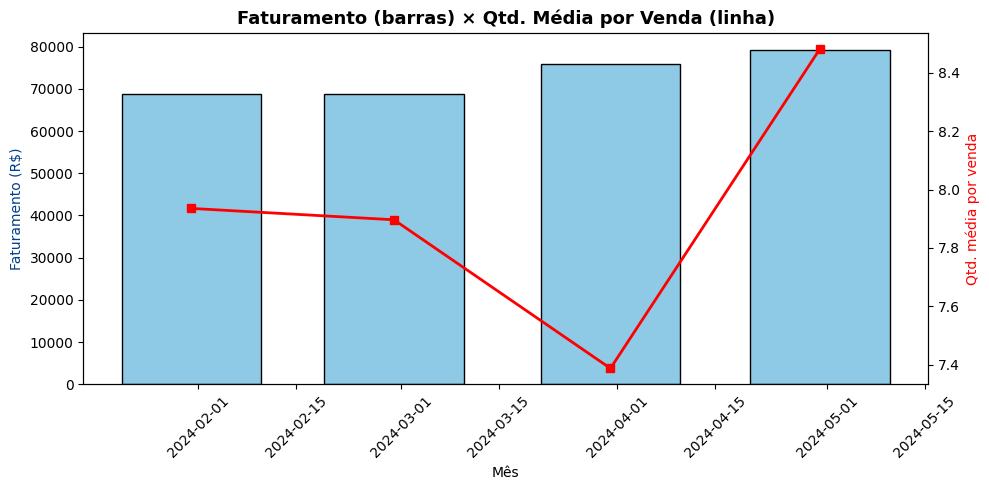

In [ ]:
df_mensal = df.set_index('data').resample('ME').agg({'valor_venda': 'sum', 'quantidade': 'sum'})

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df_mensal.index, df_mensal['valor_venda'], color='#8ecae6', edgecolor='black', label='Faturamento', width=20)
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)', color='#023e8a')
ax.tick_params(axis='x', rotation=45)

df_venda_qtd_media = df.set_index('data')['quantidade'].resample('ME').mean()

ax2 = ax.twinx()
ax2.plot(df_venda_qtd_media.index, df_venda_qtd_media.values, color='red', marker='s', linewidth=2, label='Qtd. média/venda')
ax2.set_ylabel('Qtd. média por venda', color='red')

plt.title('Faturamento (barras) × Qtd. Média por Venda (linha)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

No gráfico de linha mensal, identifique o mês de maior faturamento e adicione uma anotação com seta apontando para o pico usando ax.annotate().

Pico: 2024-04 — R$ 79,308.90


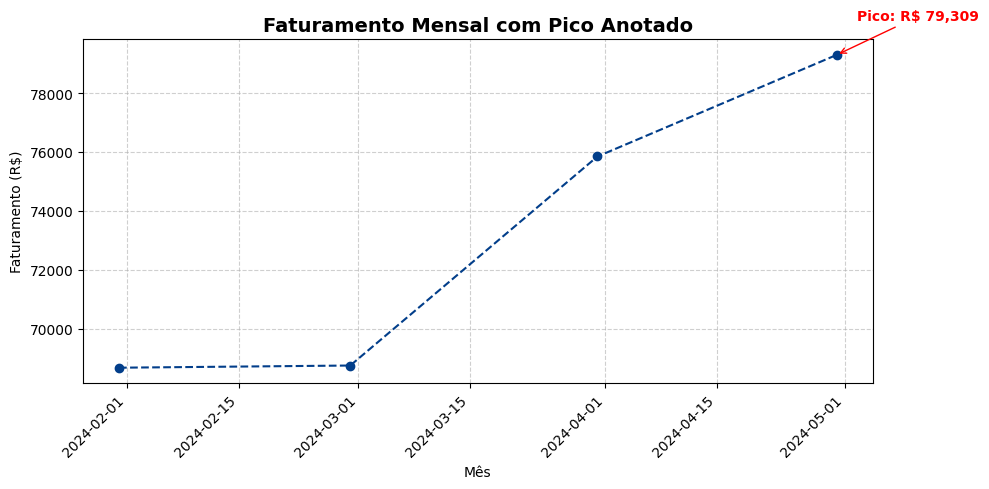

In [ ]:
mes_pico = df_mensal['valor_venda'].idxmax()
valor_pico = df_mensal['valor_venda'].max()
print(f"Pico: {mes_pico.strftime('%Y-%m')} — R$ {valor_pico:,.2f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_mensal.index, df_mensal['valor_venda'], marker='o', linestyle='--', color='#023e8a')
ax.set_title('Faturamento Mensal com Pico Anotado', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Faturamento (R$)')
ax.grid(True, linestyle='--', alpha=0.6)
ax.annotate(f'Pico: R$ {valor_pico:,.0f}',
            xy=(mes_pico, valor_pico), xycoords='data',
            xytext=(15, 25), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red', fontweight='bold')
fig.autofmt_xdate(rotation=45)
fig.tight_layout()
plt.show()

##Parte 3: Matriz de Intensidade / Heatmap (Intermediário / Avançado)

Construa uma tabela dinâmica (pd.pivot_table) somando os valores de venda agrupados por categoria nas linhas e estado nas colunas.

In [ ]:
pivot = pd.pivot_table(df, values='valor_venda', index='categoria', columns='estado', aggfunc='sum').round(2)
display(pivot)

estado,BA,MG,RJ,RS,SP
categoria,,,,,
Automotivo,8027.69,15984.08,26840.69,10034.59,26442.64
Eletronicos,13712.97,13686.01,1162.71,14377.74,8931.49
Livros,4331.11,25766.71,10591.48,19387.06,24708.70
Roupas,27380.49,9877.78,11851.17,4350.48,15122.66


Renderize essa matriz na forma de um Heatmap utilizando plt.imshow(), incluindo uma barra de cores (plt.colorbar()) e os respectivos rótulos nominais nas marcações dos eixos X (xticks) e Y (yticks).

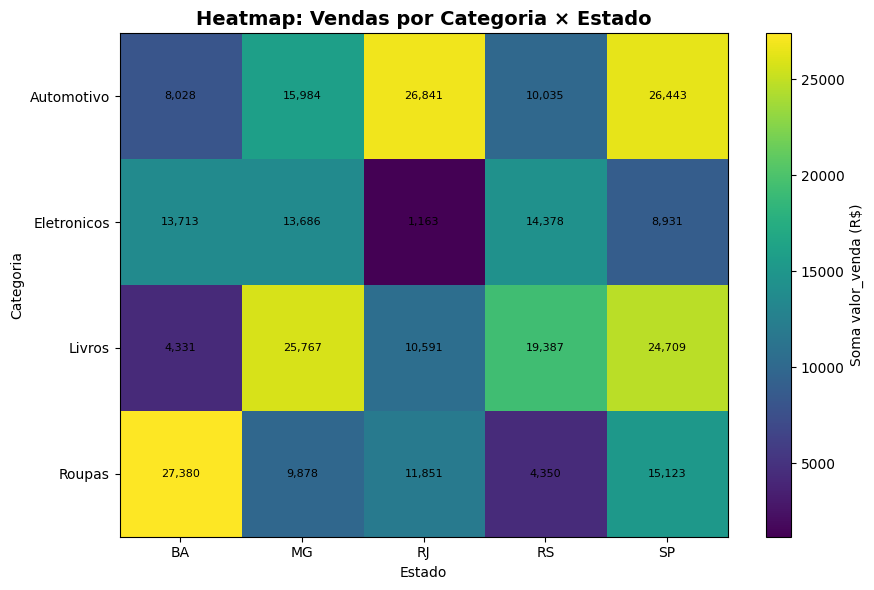

In [ ]:
plt.figure(figsize=(9, 6))
im = plt.imshow(pivot.values, aspect='auto')
plt.colorbar(im, label='Soma valor_venda (R$)')
plt.xticks(ticks=range(len(pivot.columns)), labels=pivot.columns)
plt.yticks(ticks=range(len(pivot.index)), labels=pivot.index)
plt.xlabel('Estado')
plt.ylabel('Categoria')
plt.title('Heatmap: Vendas por Categoria × Estado', fontsize=14, fontweight='bold')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f"{pivot.values[i, j]:,.0f}", ha='center', va='center', fontsize=8)

plt.tight_layout()

Salve a figura gerada no passo 8 em um arquivo de imagem 'heatmap_vendas.png' com resolução de 300 DPI e corte ajustado (bbox_inches='tight').

In [ ]:
plt.savefig('heatmap_vendas.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva como 'heatmap_vendas.png' (300 DPI, bbox_inches='tight').")

<Figure size 640x480 with 0 Axes>

Figura salva como 'heatmap_vendas.png' (300 DPI, bbox_inches='tight').
